# 06 - Manoeuvring performance and the flight envelope

References: Roskam & Lan, Chapter 12 (Secs. 12.1, 12.4-12.6); Anderson, Secs. 6.2-6.5.

In [1]:
# --- Setup -------------------------------------------------------------------
# The notebooks live in PrestazioniRoskam/, one level below the repository root,
# where the `aircraft_performance` package is. Make it importable:
import sys
import pathlib
ROOT = pathlib.Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

import aircraft_performance as ap
from aircraft_performance import units as u
from aircraft_performance.atmosphere import isa
from aircraft_performance.plotting import apply_style, reference_line
from aircraft_performance.reporting import print_table

apply_style()
print(f"aircraft_performance v{ap.__version__} ready")

from aircraft_performance import maneuvering as mnv, level_flight as lf, aerodynamics as aero

single = ap.examples.light_single_piston()
jet = ap.examples.business_jet_giv()

aircraft_performance v1.0.0 ready


## 1. The level, coordinated turn (Roskam Sec. 12.6)

In a level turn with bank angle $\phi$ the lift balances the weight vertically
and provides the centripetal force horizontally ($L\cos\phi = W$,
$L\sin\phi = \frac{W}{g}\frac{V^2}{R}$), hence (Eqns 12.50-12.52):

$$
n = \frac{L}{W} = \frac{1}{\cos\phi},\qquad
R = \frac{V^2}{g\sqrt{n^2-1}},\qquad
\omega = \frac{V}{R} = \frac{g\sqrt{n^2-1}}{V}
$$

The radius and the rate depend only on speed and load factor, i.e. on bank
angle, not on the aircraft.

In [2]:
V = 150 * u.KT
rows = []
for phi in (15, 30, 45, 60, 70):
    n = mnv.load_factor_from_bank_angle(phi)
    rows.append([phi, n, mnv.turn_radius(V, n), np.degrees(mnv.turn_rate(V, n)), 360 / np.degrees(mnv.turn_rate(V, n))])
print(f"Level turns at {V / u.KT:.0f} kt TAS")
print_table(["bank [deg]", "n", "radius [m]", "rate [deg/s]", "time for 360 deg [s]"], rows,
            ["{:.0f}", "{:.2f}", "{:.0f}", "{:.2f}", "{:.0f}"])
print("\n'Standard rate' turn (3 deg/s) at 150 kt requires a bank of "
      f"{mnv.bank_angle_from_load_factor(np.sqrt(1 + (np.radians(3) * V / u.G0) ** 2)):.1f} deg")

Level turns at 150 kt TAS
bank [deg]     n  radius [m]  rate [deg/s]  time for 360 deg [s]
----------  ----  ----------  ------------  --------------------
        15  1.04        2266          1.95                   185
        30  1.15        1052          4.20                    86
        45  1.41         607          7.28                    49
        60  2.00         351         12.61                    29
        70  2.92         221         20.01                    18

'Standard rate' turn (3 deg/s) at 150 kt requires a bank of 22.4 deg


## 2. Limits: stall, structure, thrust

The load factor that can actually be pulled is limited by (Roskam Sec. 12.6, Fig. 12.21):

1. **aerodynamics** (stall): $n \le q S C_{L_{max}}/W = (V/V_S)^2$ - *instantaneous* capability (Eqn 12.45);
   the stall speed in a turn is $V_S\sqrt n$ (Eqn 12.54);
2. **structure**: $n \le n_{lim}$ (FAR 23: up to 3.8, FAR 25: 2.5, fighters 7-9);
3. **thrust/power**: a *sustained* turn (no loss of speed or altitude) requires
   $T_{av} \ge D(n) = qS\left(C_{D_0} + K\,\dfrac{n^2W^2}{q^2S^2}\right)$ (Eqns 12.46-12.47), i.e.

   $$n_{sust} = \frac{1}{W}\sqrt{\frac{(T_{av}-qSC_{D_0})\,qS}{K}}$$

The **manoeuvring speed** $V_A = V_S\sqrt{n_{lim}}$ is where the stall and
structural limits meet: it gives the smallest instantaneous turn radius.

/tmp/ipykernel_4757/1354511445.py:4: PerformanceWarning: Maximum level speed: Mach number 1.141 exceeds the drag-divergence Mach number 0.850 of polar 'clean': the parabolic polar underestimates drag here (compressibility is not modelled).
  s = lf.level_flight_speeds(jet, h)
/tmp/ipykernel_4757/1354511445.py:4: PerformanceWarning: Maximum level speed: Mach number 1.535 exceeds the drag-divergence Mach number 0.850 of polar 'clean': the parabolic polar underestimates drag here (compressibility is not modelled).
  s = lf.level_flight_speeds(jet, h)


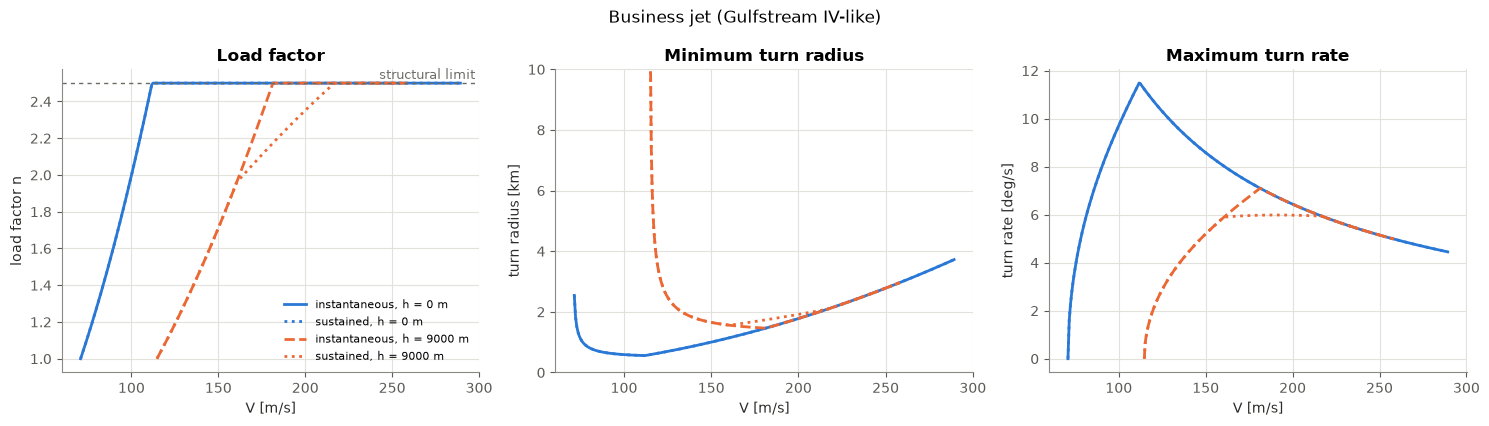

In [3]:
n_lim = 2.5          # FAR 25 minimum positive limit load factor
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for h in (0.0, 9000.0):
    s = lf.level_flight_speeds(jet, h)
    # stay below the drag-divergence Mach number, where the parabolic polar is valid
    V_top = min(s.V_max, jet.polar().mach_drag_divergence * isa(h).speed_of_sound)
    V = np.linspace(s.V_stall, V_top, 300)
    tp = mnv.turn_performance(jet, h, V, n_limit=n_lim)
    line, = axes[0].plot(V, tp.n_instantaneous, label=f"instantaneous, h = {h:.0f} m")
    axes[0].plot(V, tp.n_sustained_limited, color=line.get_color(), linestyle=":", label=f"sustained, h = {h:.0f} m")
    axes[1].plot(V, tp.radius("instantaneous") / 1000, color=line.get_color(), label=f"instantaneous, {h:.0f} m")
    axes[1].plot(V, tp.radius("sustained") / 1000, color=line.get_color(), linestyle=":", label=f"sustained, {h:.0f} m")
    axes[2].plot(V, np.degrees(tp.rate("instantaneous")), color=line.get_color(), label=f"instantaneous, {h:.0f} m")
    axes[2].plot(V, np.degrees(tp.rate("sustained")), color=line.get_color(), linestyle=":", label=f"sustained, {h:.0f} m")
axes[0].set_ylabel("load factor n"); axes[0].set_title("Load factor")
reference_line(axes[0], n_lim, orientation="h", label="structural limit")
axes[1].set_ylabel("turn radius [km]"); axes[1].set_ylim(0, 10); axes[1].set_title("Minimum turn radius")
axes[2].set_ylabel("turn rate [deg/s]"); axes[2].set_title("Maximum turn rate")
for ax in axes:
    ax.set_xlabel("V [m/s]")
axes[0].legend(fontsize=8)
fig.suptitle(jet.name)
plt.tight_layout()
plt.show()

* At sea level the jet can *sustain* the structural limit over a wide speed
  range: its turns are structure- and stall-limited.
* At 9,000 m the thrust has lapsed and the sustained load factor collapses:
  high-altitude manoeuvring is thrust-limited (Roskam Fig. 12.21b). The sustained
  load factor would drop to 1 at the maximum level speed (no turn possible);
  with this polar that happens beyond the drag-divergence Mach number, so the
  curves are cut at $M_{DD}=0.85$.

### Check: Anderson Example 6.2

For constant thrust and a parabolic polar, the maximum *sustained* turn rate
occurs at $V = \sqrt{2(W/S)/\rho}\,(K/C_{D_0})^{1/4}$ with
$n = \sqrt{2\,(T/W)/\sqrt{KC_{D_0}} - 1}$ (Anderson Eqns 6.34-6.35):
3.16 for the Gulfstream-like jet at sea level (ignoring the stall and structural limits).

In [4]:
W, S, rho0 = jet.weight, jet.wing_area, isa(0.0).density
V_star = np.sqrt(2 * W / S / rho0) * (jet.polar().K / jet.polar().CD0) ** 0.25
n_star = mnv.sustained_load_factor(jet, V_star, 0.0)
print(f"V = {V_star / u.FT:.0f} ft/s (Anderson: 386 ft/s), n = {n_star:.2f} (3.16), "
      f"omega = {np.degrees(mnv.turn_rate(V_star, n_star)):.1f} deg/s (14.3)")
V_S_n = aero.stall_speed(W, S, rho0, jet.config().CL_max, load_factor=n_star)
print(f"...but the stall speed at n = {n_star:.2f} is {V_S_n / u.FT:.0f} ft/s: the point is (slightly) beyond the stall"
      " limit, as Anderson remarks.")

V = 386 ft/s (Anderson: 386 ft/s), n = 3.15 (3.16), omega = 14.3 deg/s (14.3)
...but the stall speed at n = 3.15 is 412 ft/s: the point is (slightly) beyond the stall limit, as Anderson remarks.


## 3. The V-n diagram (Roskam Sec. 12.4)

The V-n diagram collects the combinations of equivalent airspeed and load
factor the structure is designed for. For **FAR 23** (Sec. 12.4.1):

* limit load factors (Eqns 12.26-12.28): normal category
  $n_{lim} = 2.1 + \dfrac{24{,}000}{W + 10{,}000}$ (W in lb), at most 3.8;
  utility 4.4; acrobatic 6.0; negative limit $-0.4\,n_{lim}$ ($-0.5$ acrobatic);
* stall lines $n = \rho_0 V_E^2 S\,C_{N_{max}}/(2W)$ with $C_{N_{max}}\approx1.1C_{L_{max}}$ (Eqn 12.17);
* design cruising speed $V_C \ge 33\sqrt{W/S}$ kt ($W/S$ in lb/ft$^2$, Eqn 12.20), need not
  exceed $0.9V_H$; design dive speed $V_D \ge 1.25V_C$ (Eqn 12.21);
* manoeuvring speed $V_A = V_S\sqrt{n_{lim}}$ (Eqn 12.19).

Gust lines (Eqns 12.29-12.35) are not drawn here.

                                            quantity         value
----------------------------------------------------  ------------
                           n_lim positive / negative  3.80 / -1.52
                           V_S (1 g, C_N max) [KEAS]          48.6
                        V_A = V_S sqrt(n_lim) [KEAS]          94.8
V_C [KEAS] (33 sqrt(W/S) = 124 kt, 0.9 V_H = 113 kt)         113.3
                               V_D = 1.25 V_C [KEAS]         141.6


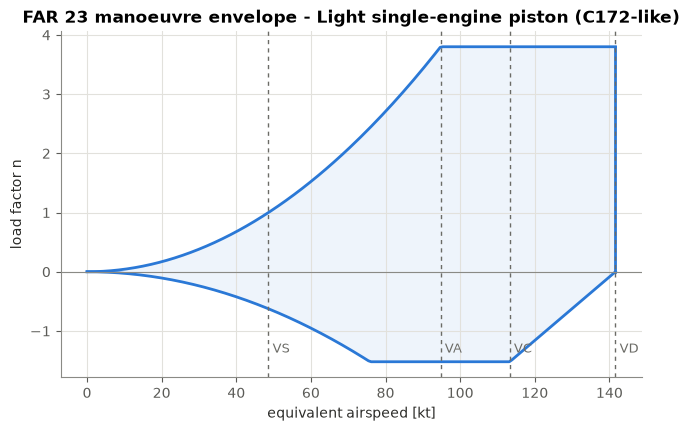

In [5]:
W = single.weight
n_pos, n_neg = mnv.far23_limit_load_factors(W, "normal")
V_H = lf.level_flight_speeds(single, 0.0).V_max
WS_psf = single.wing_loading / u.PSF
V_C = min(33.0 * np.sqrt(WS_psf) * u.KT, 0.9 * V_H)
V_D = 1.25 * V_C
vn = mnv.vn_maneuver_diagram(W, single.wing_area, single.config().CL_max, 1.0, n_pos, n_neg, V_C, V_D)
print_table(["quantity", "value"],
            [["n_lim positive / negative", f"{n_pos:.2f} / {n_neg:.2f}"],
             ["V_S (1 g, C_N max) [KEAS]", f"{vn['V_S'] / u.KT:.1f}"],
             ["V_A = V_S sqrt(n_lim) [KEAS]", f"{vn['V_A'] / u.KT:.1f}"],
             ["V_C [KEAS] (33 sqrt(W/S) = {:.0f} kt, 0.9 V_H = {:.0f} kt)".format(33 * np.sqrt(WS_psf), 0.9 * V_H / u.KT),
              f"{V_C / u.KT:.1f}"],
             ["V_D = 1.25 V_C [KEAS]", f"{V_D / u.KT:.1f}"]], ["{}", "{}"])

fig, ax = plt.subplots()
Vk = vn["V"] / u.KT
ax.plot(Vk, vn["n_upper"], color="#2a78d6", linestyle="-")
ax.plot(Vk, vn["n_lower"], color="#2a78d6", linestyle="-")
ax.plot([Vk[-1], Vk[-1]], [vn["n_lower"][-1], vn["n_upper"][-1]], color="#2a78d6", linestyle="-")
ax.fill_between(Vk, vn["n_lower"], vn["n_upper"], color="#2a78d6", alpha=0.08)
for name in ("V_S", "V_A", "V_C", "V_D"):
    reference_line(ax, vn[name] / u.KT, label=name.replace("_", ""), label_position=0.12)
ax.axhline(0, color="#8a8a85", linewidth=0.8)
ax.set_xlabel("equivalent airspeed [kt]"); ax.set_ylabel("load factor n")
ax.set_title(f"FAR 23 manoeuvre envelope - {single.name}")
plt.show()

## 4. Exercises

1. Build the V-n diagram of the same aircraft in the *utility* category and
   compare $V_A$.
2. For the light single at 1,500 m, plot the minimum sustained turn radius
   versus speed and find the speed at which it is achieved.
3. Roskam Example 12.1: an aircraft in level flight at 300 ft/s enters a level
   turn of 2,850 ft radius at constant angle of attack and speed-adjusted
   thrust. Verify that the drag in the turn is about 5.1 times the level-flight
   drag (use $\sin\phi = V^2/(gR)$ at constant $C_L$).